In [4]:
import pandas as pd
import json
import re

df = pd.read_csv('results_final_flattened.csv', encoding='latin-1')
extracted_data = []

for index, row in df.iterrows():
    text = str(row.get('mistral_audit_response', ''))
    row_data = {}
    
    if text.strip() not in ['', 'nan'] and not text.startswith('ERREUR'):
        json_match = re.search(r'<JSON>(.*?)</JSON>', text, re.DOTALL)
        summary_match = re.search(r'<SUMMARY>(.*?)</SUMMARY>', text, re.DOTALL)
        eval_match = re.search(r'<EVAL>(.*?)</EVAL>', text, re.DOTALL)
        
        json_str = json_match.group(1).strip() if json_match else text.strip()
            
        json_str = re.sub(r'^```json\s*', '', json_str)
        json_str = re.sub(r'^```\s*', '', json_str)
        json_str = re.sub(r'\s*```$', '', json_str)
        json_str = json_str.strip()

        start_idx = json_str.find('{')
        end_idx = json_str.rfind('}')
        
        if start_idx != -1 and end_idx != -1:
            json_str = json_str[start_idx:end_idx+1]
            try:
                parsed = json.loads(json_str)
                for k, v in parsed.items():
                    if str(v) != "NaN":
                        row_data[k] = v
            except ValueError:
                pass
                
        if summary_match:
            row_data['summary'] = summary_match.group(1).strip()
            
        if eval_match:
            row_data['eval'] = eval_match.group(1).strip()
            
    extracted_data.append(row_data)

df_extracted = pd.DataFrame(extracted_data, index=df.index)

for col in df_extracted.columns:
    if col in df.columns:
        df[col] = df[col].astype(object)
        mask = df_extracted[col].notna()
        df.loc[mask, col] = df_extracted.loc[mask, col]
    else:
        df[col] = df_extracted[col]

df.to_csv('results_final_flattened_0.csv', index=False, encoding='utf-8')

In [6]:
df.head(20)

,company,year,quarter,tariffs_summary,tariffs_effect_any,tariffs_effect_current,tariffs_effect_future,tariffs_investment_up_imposing,tariffs_investment_up_receiving,tariffs_investment_up_third_party,...,exports_correction,tariffs_hs_chapter_explanation,tariffs_hs_heading_explanation,tariffs_hs_subheading_explanation,sanctions_hs_chapter_explanation,sanctions_hs_heading_explanation,sanctions_hs_subheading_explanation,exports_hs_chapter_explanation,exports_hs_heading_explanation,exports_hs_subheading_explanation
0,Apple Inc. (AAPL),2025.0,Q1,[Part 5] Apple is monitoring the situation reg...,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Apple Inc. (AAPL),2025.0,Q3,"[Part 1] Apple is affected by tariffs, with es...",1.0,1.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Microsoft Corporation (MSFT),2025.0,Q1,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Microsoft Corporation (MSFT),2025.0,Q2,[Part 3] Microsoft's Windows OEM revenue may b...,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Microsoft Corporation (MSFT),2025.0,Q4,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Nvidia Corporation (NVDA),2025.0,Q1,"[Part 1] NVIDIA is affected by tariffs, with e...",1.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Nvidia Corporation (NVDA),2025.0,Q2,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Nvidia Corporation (NVDA),2025.0,Q3,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Nvidia Corporation (NVDA),2025.0,Q4,[Part 5] The company may be affected by tariff...,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Alphabet Inc. (GOOGL),2025.0,Q2,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


BACI codes map : HS2 (2001), HS4 (48), HS6 (5)


/var/folders/0w/lf6hd86155sgzz5x85l_z4wm0000gn/T/ipykernel_2969/435738799.py:87: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi_per_product = df.groupby(['k_str', 'description']).apply(calc_hhi).reset_index(name='hhi')


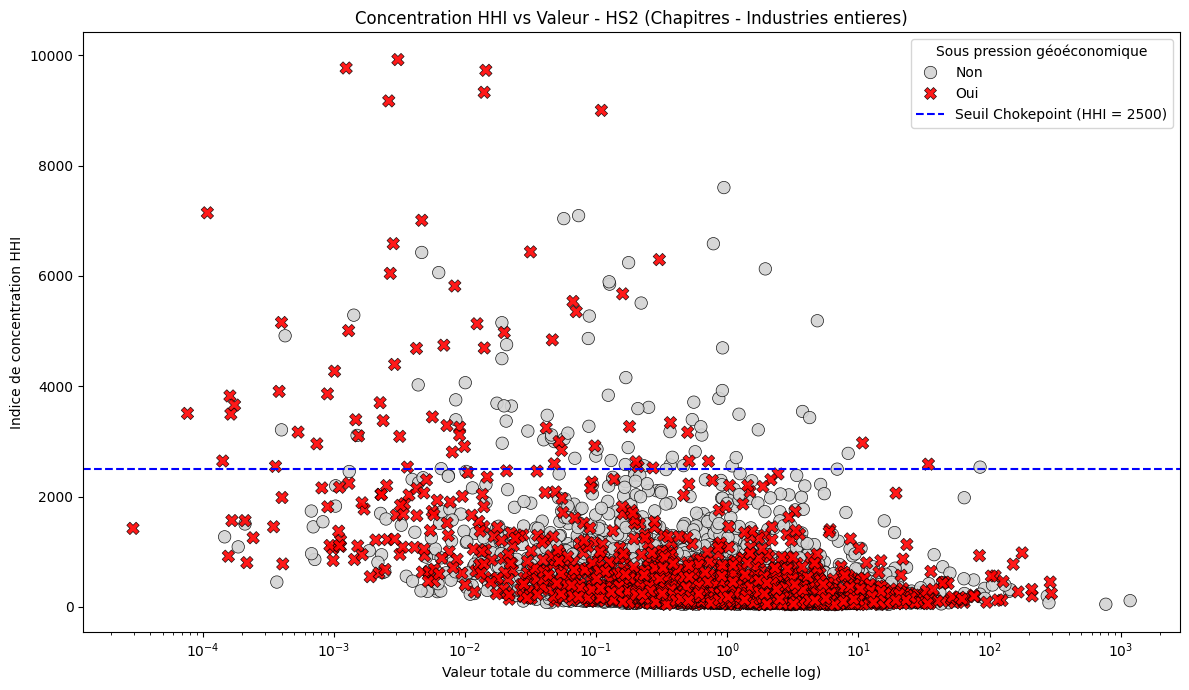

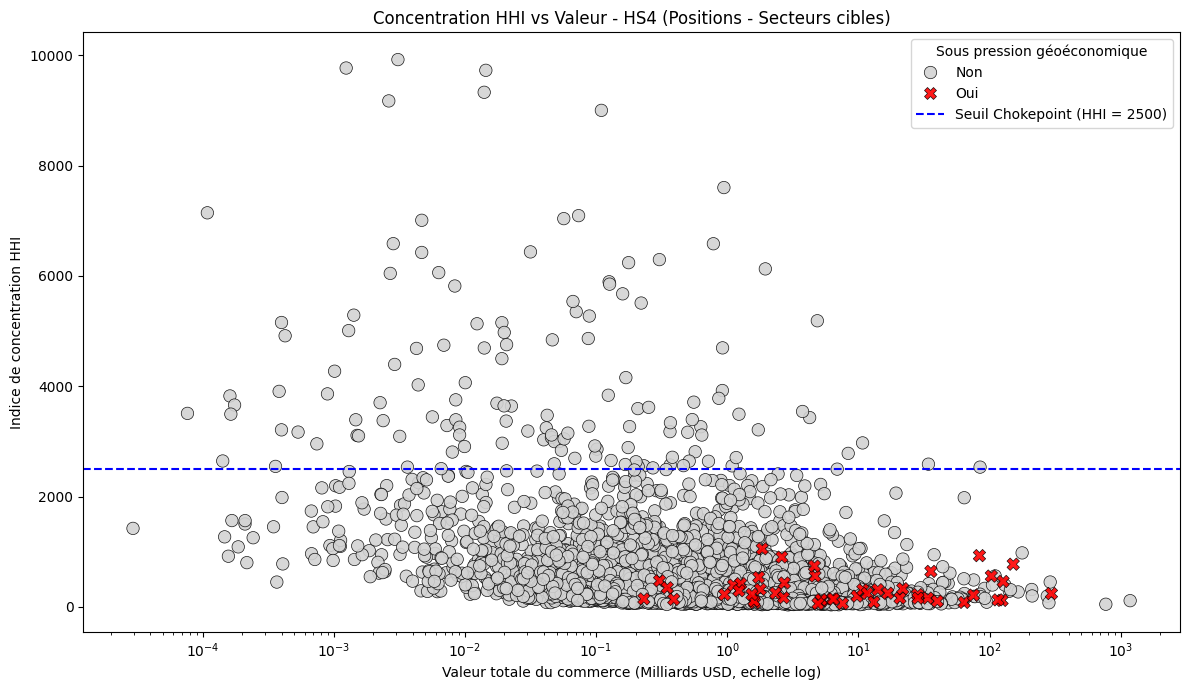

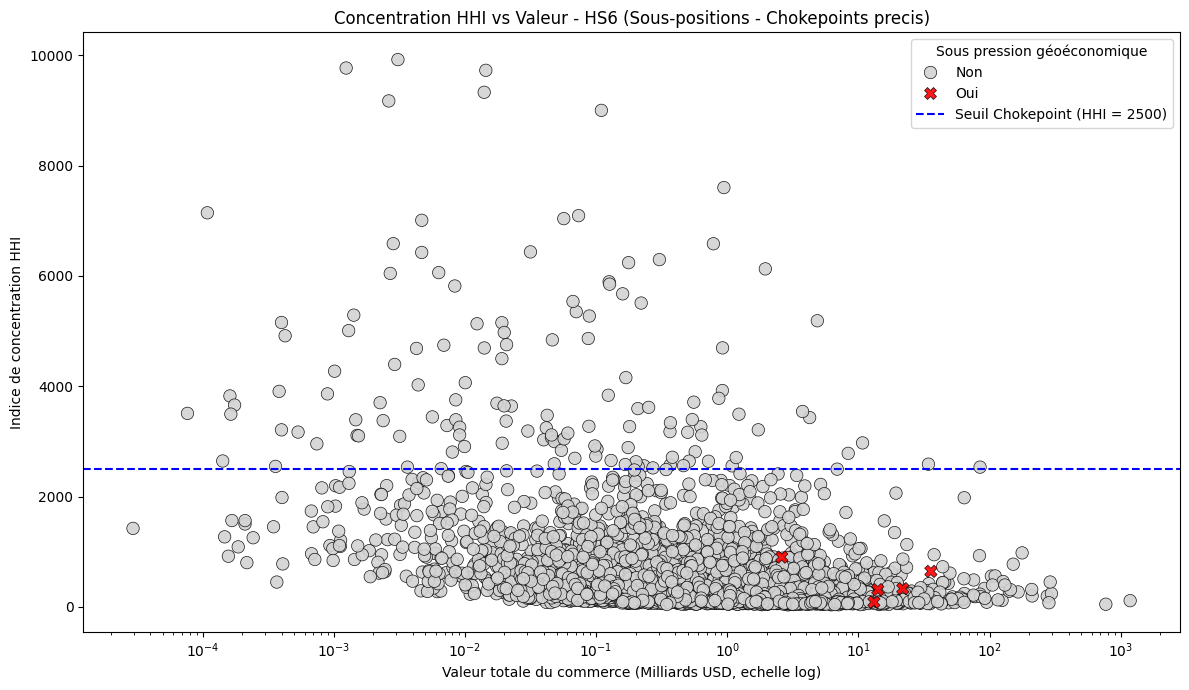

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

baci_df = pd.read_csv('BACI_HS17_Y2018_V202601.csv', encoding='latin-1')
countries_df = pd.read_csv('country_codes_V202601.csv', encoding='latin-1')
hs_df = pd.read_csv('product_codes_HS17_V202601.csv', encoding='latin-1')
hs_iu_df = pd.read_csv('JobID-65_Concordance_HS_to_IU.csv', encoding='latin-1')
pressure_df = pd.read_csv('results_final_flattened_0.csv', encoding='latin-1')

pressure_df = pressure_df[pressure_df['mistral_audit_response'].notna()]
pressure_df = pressure_df[~pressure_df['mistral_audit_response'].astype(str).str.startswith('ERREUR')]

baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)
hs_df['code_str'] = hs_df['code'].astype(str).str.zfill(6)

hs_code_col_iu = [c for c in hs_iu_df.columns if 'hs' in c.lower() or 'code' in c.lower()][0]
hs_iu_df['hs_str'] = hs_iu_df[hs_code_col_iu].astype(str).str.zfill(6)

df = baci_df.merge(
    countries_df[['country_code', 'country_name', 'country_iso3']], 
    left_on='i', 
    right_on='country_code', 
    how='left'
).rename(columns={'country_name': 'exporter_name', 'country_iso3': 'exporter_iso3'}).drop(columns=['country_code'])

df = df.merge(
    countries_df[['country_code', 'country_name', 'country_iso3']], 
    left_on='j', 
    right_on='country_code', 
    how='left'
).rename(columns={'country_name': 'importer_name', 'country_iso3': 'importer_iso3'}).drop(columns=['country_code'])

df = df.merge(
    hs_df[['code_str', 'description']], 
    left_on='k_str', 
    right_on='code_str', 
    how='left'
).drop(columns=['code_str'])

iu_cols = [c for c in hs_iu_df.columns if c != hs_code_col_iu and c != 'hs_str']
df = df.merge(
    hs_iu_df[['hs_str'] + iu_cols], 
    left_on='k_str', 
    right_on='hs_str', 
    how='left'
).drop(columns=['hs_str'])

baci_unique_codes = df['k_str'].unique()

hs2_codes = set()
hs4_codes = set()
hs6_codes = set()

hs_cols = [c for c in pressure_df.columns if 'hs_' in c and 'explanation' not in c]

for col in hs_cols:
    vals = pressure_df[col].dropna().astype(str).str.strip()
    for v_item in vals:
        if v_item.lower() not in ['nan', 'none', 'null', '']:
            for code_part in v_item.split(','):
                match = re.search(r'(\d+[\.\d]*)', code_part)
                if match:
                    raw_code = match.group(1).replace('.', '')
                    if len(raw_code) == 1:
                        raw_code = '0' + raw_code
                    
                    if len(raw_code) == 2:
                        hs2_codes.add(raw_code)
                    elif 3 <= len(raw_code) <= 4:
                        hs4_codes.add(raw_code.zfill(4))
                    elif len(raw_code) >= 5:
                        hs6_codes.add(raw_code[:6].zfill(6))

baci_under_hs2 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs2_codes)])
baci_under_hs4 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs4_codes)])
baci_under_hs6 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs6_codes)])

print(f"BACI codes map : HS2 ({len(baci_under_hs2)}), HS4 ({len(baci_under_hs4)}), HS6 ({len(baci_under_hs6)})")

def calc_hhi(group):
    shares = (group['v'] / group['v'].sum()) * 100
    return (shares ** 2).sum()

hhi_per_product = df.groupby(['k_str', 'description']).apply(calc_hhi).reset_index(name='hhi')
hhi_with_val = hhi_per_product.merge(df.groupby('k_str')['v'].sum().reset_index(), on='k_str')
hhi_with_val['v_billion'] = hhi_with_val['v'] / 1e6

echelles = {
    'HS2 (Chapitres - Industries entieres)': (baci_under_hs2, 'HS2'),
    'HS4 (Positions - Secteurs cibles)': (baci_under_hs4, 'HS4'),
    'HS6 (Sous-positions - Chokepoints precis)': (baci_under_hs6, 'HS6')
}

for titre, (code_set, file_suffix) in echelles.items():
    if len(code_set) == 0:
        continue
        
    df_plot = hhi_with_val.copy()
    df_plot['is_under_pressure'] = df_plot['k_str'].isin(code_set)
    df_plot['Statut'] = np.where(df_plot['is_under_pressure'], 'Oui', 'Non')
    df_plot = df_plot.sort_values(by='is_under_pressure')
    
    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=df_plot, 
        x='v_billion', 
        y='hhi', 
        hue='Statut', 
        style='Statut',
        palette={'Oui': 'red', 'Non': 'lightgrey'}, 
        markers={'Oui': 'X', 'Non': 'o'},
        alpha=0.9,
        s=80,
        edgecolor='black',
        linewidth=0.5
    )
    plt.axhline(2500, color='blue', linestyle='--', label='Seuil Chokepoint (HHI = 2500)')
    plt.xscale('log')
    plt.title(f'Concentration HHI vs Valeur - {titre}')
    plt.xlabel('Valeur totale du commerce (Milliards USD, echelle log)')
    plt.ylabel('Indice de concentration HHI')
    plt.legend(title='Sous pression géoéconomique')
    plt.tight_layout()
    plt.savefig(f'chokepoints_hhi_{file_suffix}.png')
    plt.show()
    plt.close()

/var/folders/0w/lf6hd86155sgzz5x85l_z4wm0000gn/T/ipykernel_2969/2555585068.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  us_import_hhi_df = us_imports.groupby('k_str').apply(calc_us_import_hhi).reset_index(name='us_import_hhi')


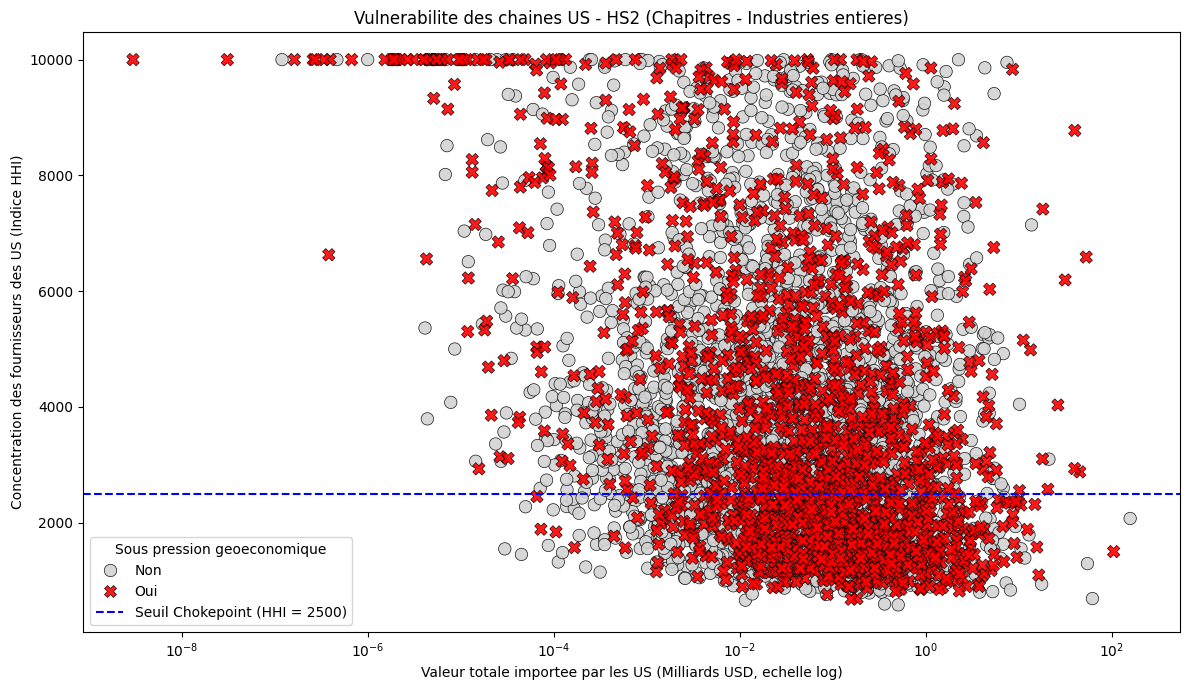

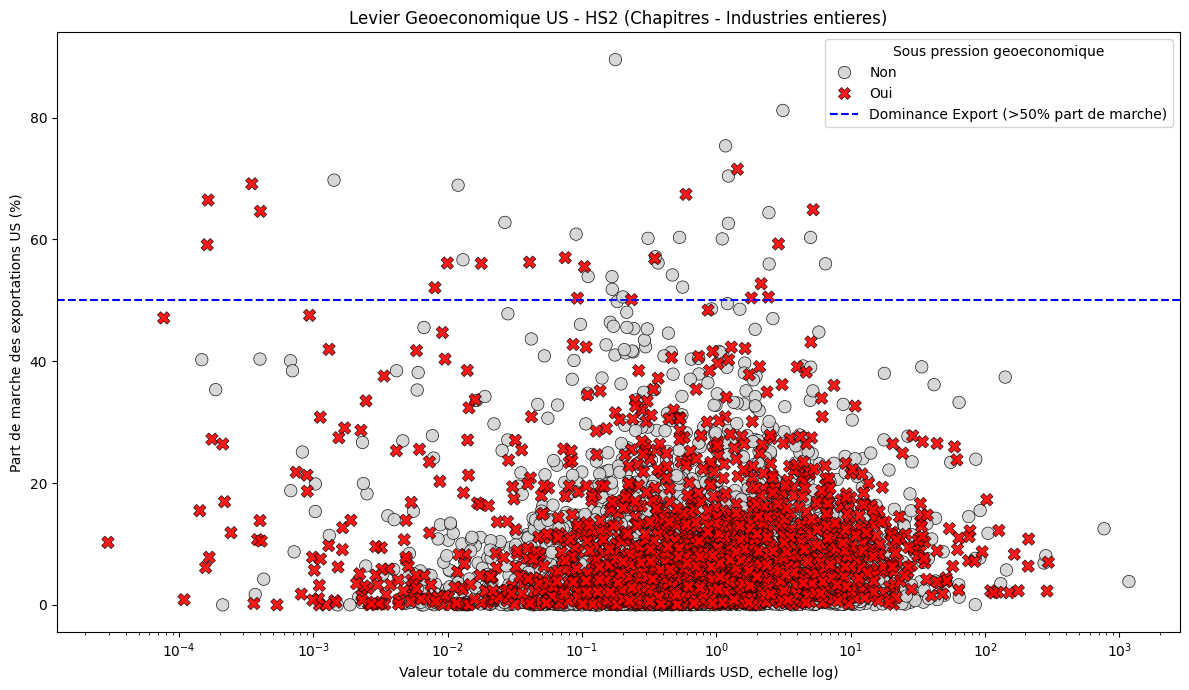

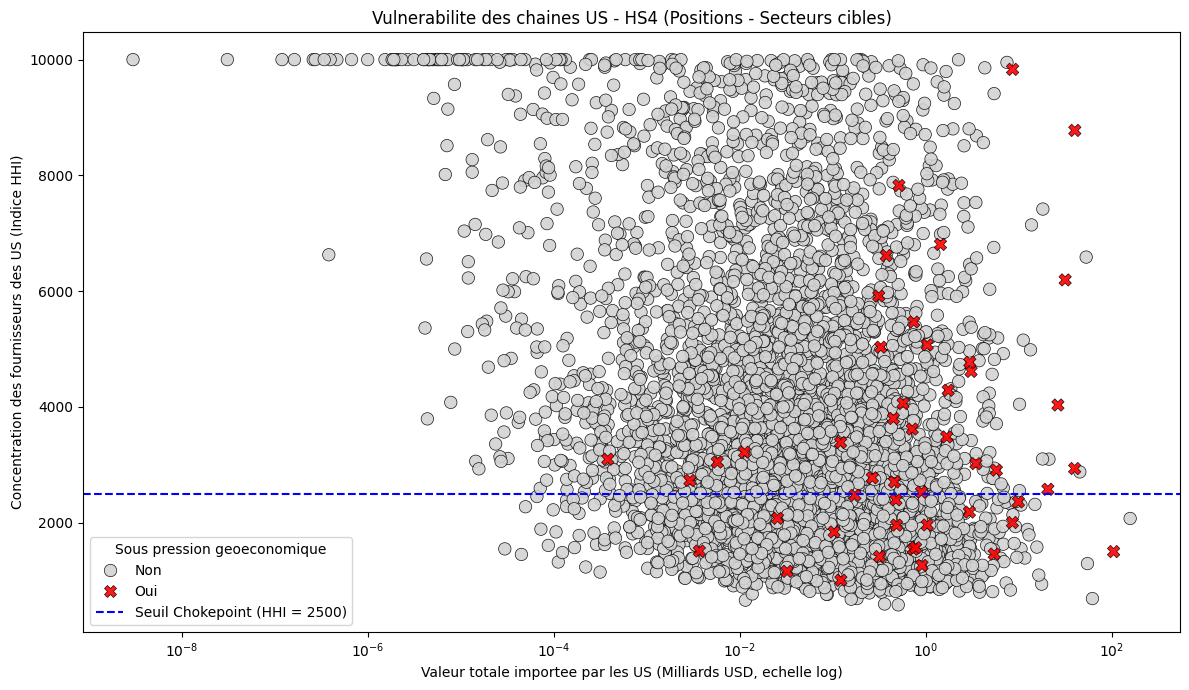

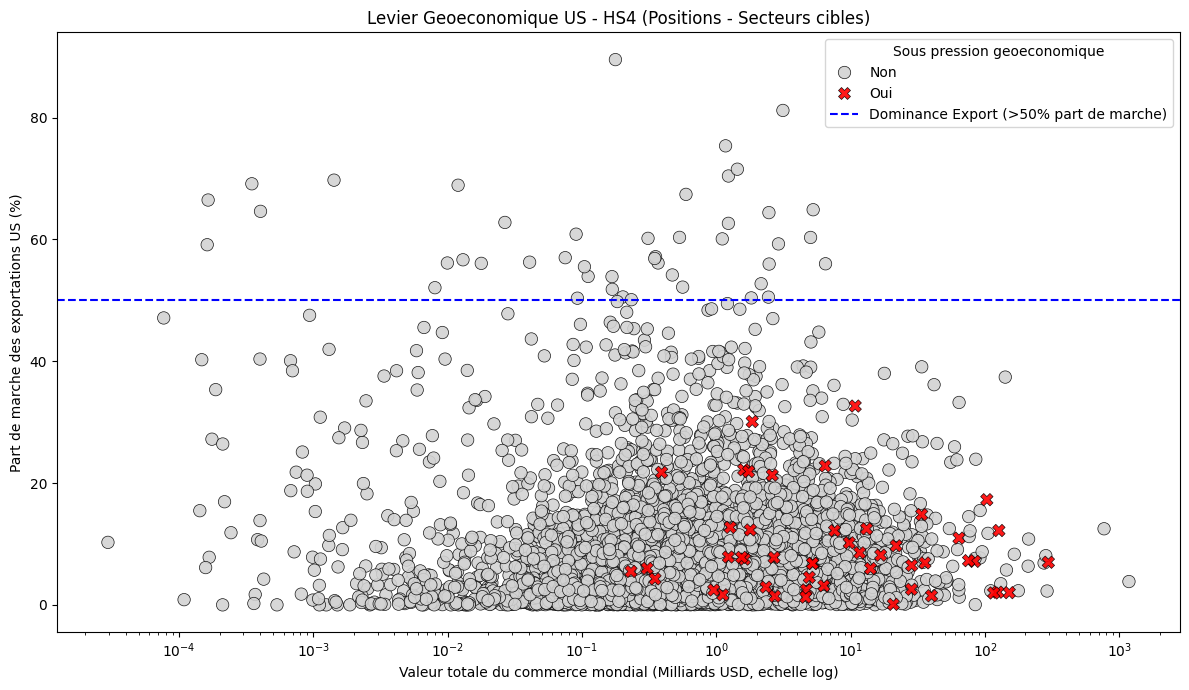

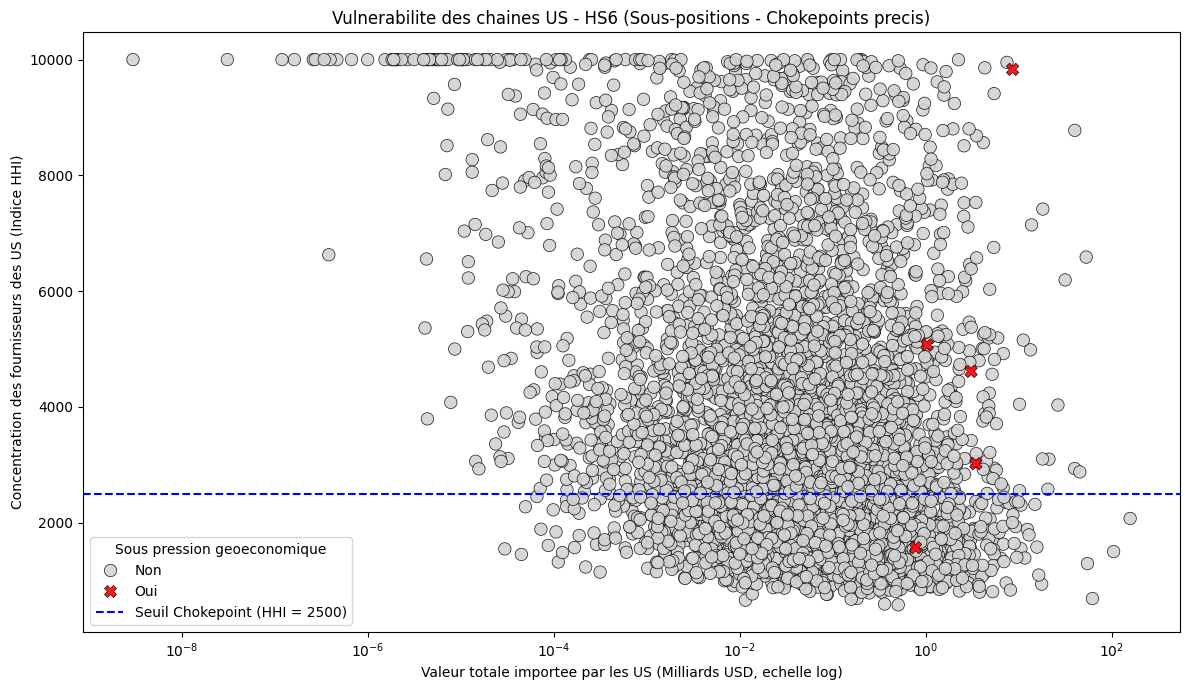

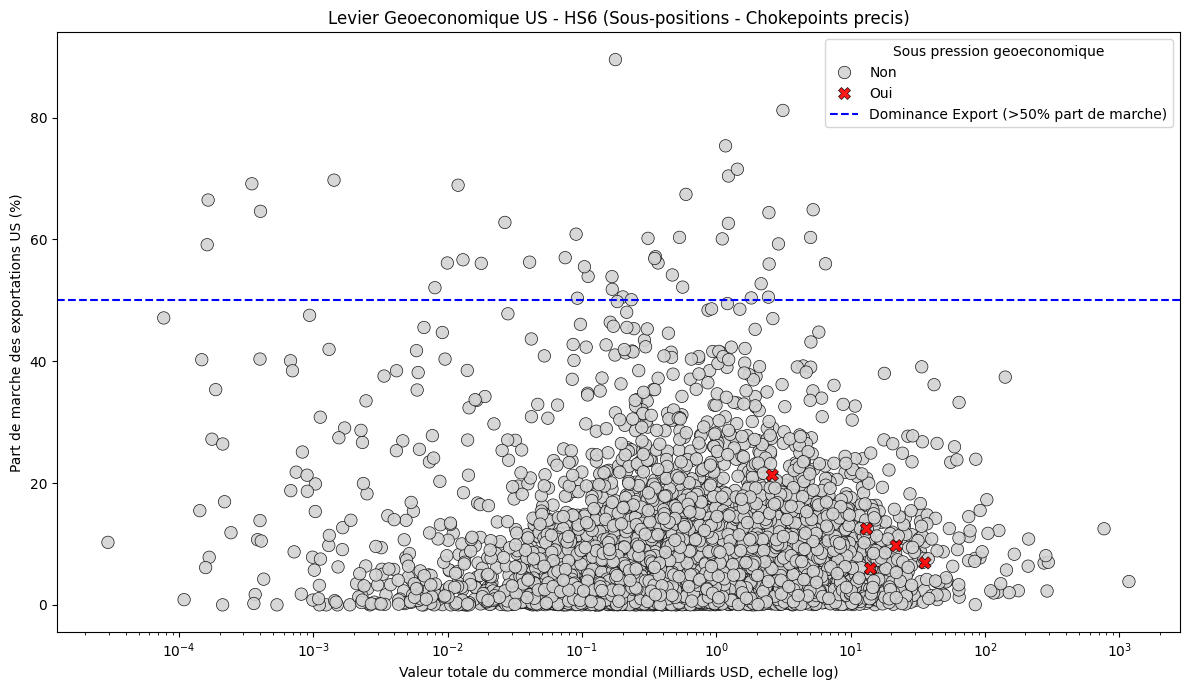

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

baci_df = pd.read_csv('BACI_HS17_Y2018_V202601.csv', encoding='latin-1')
countries_df = pd.read_csv('country_codes_V202601.csv', encoding='latin-1')
pressure_df = pd.read_csv('results_final_flattened_0.csv', encoding='latin-1')

pressure_df = pressure_df[pressure_df['mistral_audit_response'].notna()]
pressure_df = pressure_df[~pressure_df['mistral_audit_response'].astype(str).str.startswith('ERREUR')]

baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)

us_code_row = countries_df[countries_df['country_iso3'] == 'USA']
us_code = us_code_row['country_code'].iloc[0] if not us_code_row.empty else 840

baci_unique_codes = baci_df['k_str'].unique()

hs2_codes = set()
hs4_codes = set()
hs6_codes = set()

hs_cols = [c for c in pressure_df.columns if 'hs_' in c and 'explanation' not in c]

for col in hs_cols:
    vals = pressure_df[col].dropna().astype(str).str.strip()
    for v_item in vals:
        if v_item.lower() not in ['nan', 'none', 'null', '']:
            for code_part in v_item.split(','):
                match = re.search(r'(\d+[\.\d]*)', code_part)
                if match:
                    raw_code = match.group(1).replace('.', '')
                    if len(raw_code) == 1:
                        raw_code = '0' + raw_code
                    
                    if len(raw_code) == 2:
                        hs2_codes.add(raw_code)
                    elif 3 <= len(raw_code) <= 4:
                        hs4_codes.add(raw_code.zfill(4))
                    elif len(raw_code) >= 5:
                        hs6_codes.add(raw_code[:6].zfill(6))

baci_under_hs2 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs2_codes)])
baci_under_hs4 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs4_codes)])
baci_under_hs6 = set([b for b in baci_unique_codes if any(b.startswith(c) for c in hs6_codes)])

echelles = {
    'HS2 (Chapitres - Industries entieres)': (baci_under_hs2, 'HS2'),
    'HS4 (Positions - Secteurs cibles)': (baci_under_hs4, 'HS4'),
    'HS6 (Sous-positions - Chokepoints precis)': (baci_under_hs6, 'HS6')
}

us_imports = baci_df[baci_df['j'] == us_code].copy()
us_import_totals = us_imports.groupby('k_str')['v'].sum().reset_index(name='us_total_import')

def calc_us_import_hhi(group):
    shares = (group['v'] / group['v'].sum()) * 100
    return (shares ** 2).sum()

us_import_hhi_df = us_imports.groupby('k_str').apply(calc_us_import_hhi).reset_index(name='us_import_hhi')
base_us_import_analysis = us_import_totals.merge(us_import_hhi_df, on='k_str')
base_us_import_analysis['v_billion'] = base_us_import_analysis['us_total_import'] / 1e6

global_exports = baci_df.groupby('k_str')['v'].sum().reset_index(name='global_total_export')
us_exports = baci_df[baci_df['i'] == us_code].groupby('k_str')['v'].sum().reset_index(name='us_export')
base_us_export_analysis = global_exports.merge(us_exports, on='k_str', how='left').fillna({'us_export': 0})
base_us_export_analysis['us_export_share_%'] = (base_us_export_analysis['us_export'] / base_us_export_analysis['global_total_export']) * 100
base_us_export_analysis['global_v_billion'] = base_us_export_analysis['global_total_export'] / 1e6

for titre, (code_set, file_suffix) in echelles.items():
    if len(code_set) == 0:
        continue

    us_import_analysis = base_us_import_analysis.copy()
    us_import_analysis['is_under_pressure'] = us_import_analysis['k_str'].isin(code_set)
    us_import_analysis['Statut'] = np.where(us_import_analysis['is_under_pressure'], 'Oui', 'Non')
    us_import_analysis = us_import_analysis.sort_values(by='is_under_pressure')

    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=us_import_analysis, 
        x='v_billion', 
        y='us_import_hhi', 
        hue='Statut', 
        style='Statut',
        palette={'Oui': 'red', 'Non': 'lightgrey'}, 
        markers={'Oui': 'X', 'Non': 'o'},
        alpha=0.9,
        s=80,
        edgecolor='black',
        linewidth=0.5
    )
    plt.axhline(2500, color='blue', linestyle='--', label='Seuil Chokepoint (HHI = 2500)')
    plt.xscale('log')
    plt.title(f'Vulnerabilite des chaines US - {titre}')
    plt.xlabel('Valeur totale importee par les US (Milliards USD, echelle log)')
    plt.ylabel('Concentration des fournisseurs des US (Indice HHI)')
    plt.legend(title='Sous pression geoeconomique')
    plt.tight_layout()
    plt.savefig(f'us_import_vulnerability_{file_suffix}.png')
    plt.show()
    plt.close()

    us_export_analysis = base_us_export_analysis.copy()
    us_export_analysis['is_under_pressure'] = us_export_analysis['k_str'].isin(code_set)
    us_export_analysis['Statut'] = np.where(us_export_analysis['is_under_pressure'], 'Oui', 'Non')
    us_export_analysis = us_export_analysis.sort_values(by='is_under_pressure')

    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=us_export_analysis, 
        x='global_v_billion', 
        y='us_export_share_%', 
        hue='Statut', 
        style='Statut',
        palette={'Oui': 'red', 'Non': 'lightgrey'}, 
        markers={'Oui': 'X', 'Non': 'o'},
        alpha=0.9,
        s=80,
        edgecolor='black',
        linewidth=0.5
    )
    plt.axhline(50, color='blue', linestyle='--', label='Dominance Export (>50% part de marche)')
    plt.xscale('log')
    plt.title(f'Levier Geoeconomique US - {titre}')
    plt.xlabel('Valeur totale du commerce mondial (Milliards USD, echelle log)')
    plt.ylabel('Part de marche des exportations US (%)')
    plt.legend(title='Sous pression geoeconomique')
    plt.tight_layout()
    plt.savefig(f'us_export_leverage_{file_suffix}.png')
    plt.show()
    plt.close()

Chargement des fichiers CSV en cours...
Chargement termine.
Extraction des codes douaniers depuis les transcripts...
Codes trouves - Tariffs : HS2(14), HS4(2), HS6(8)
Codes trouves - Sanctions : HS2(2), HS4(1), HS6(1)
Codes trouves - Exports : HS2(2), HS4(3), HS6(3)

--- Agregation et calcul HHI pour : HS2 (Chapters - Entire Industries) ---
Affichage du graphique US Import Vulnerability (HS2_agg)


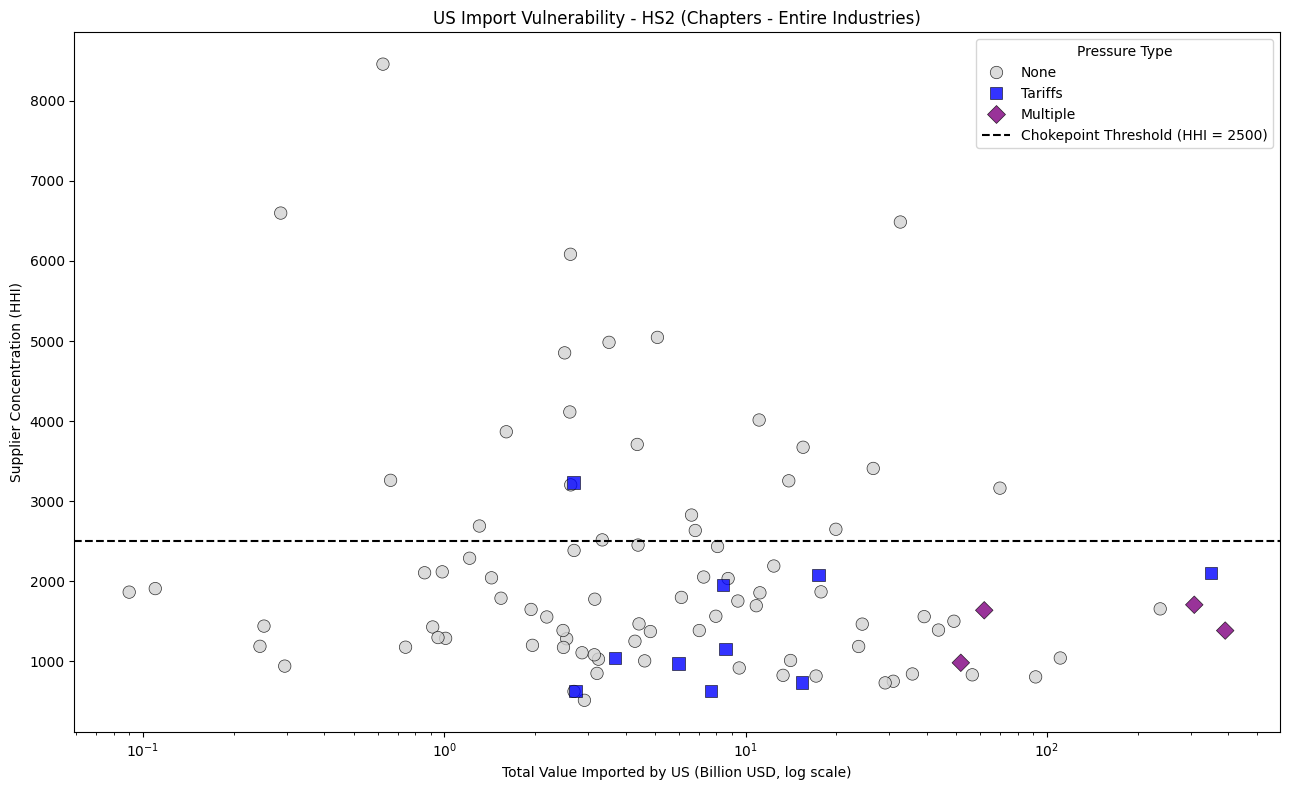

Affichage du graphique US Export Leverage (HS2_agg)


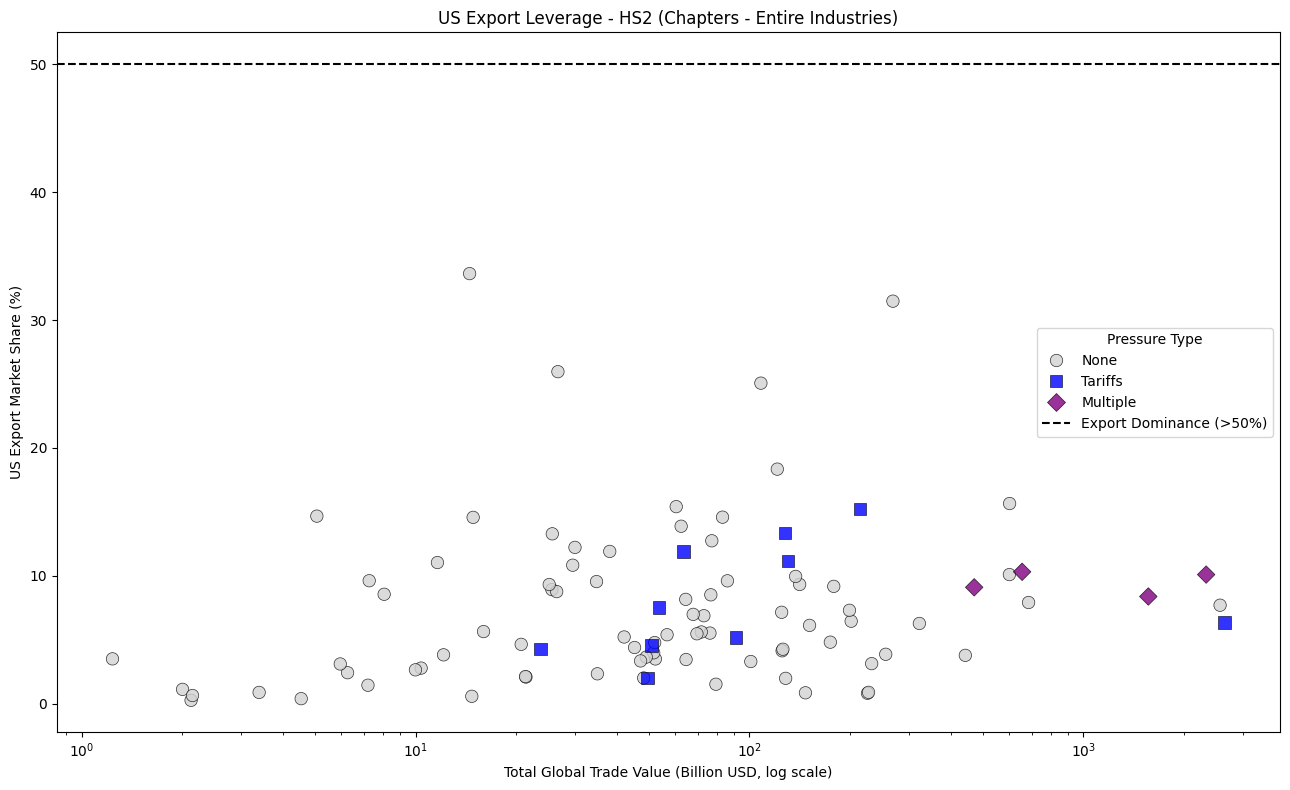


--- Agregation et calcul HHI pour : HS4 (Headings - Targeted Sectors) ---
Affichage du graphique US Import Vulnerability (HS4_agg)


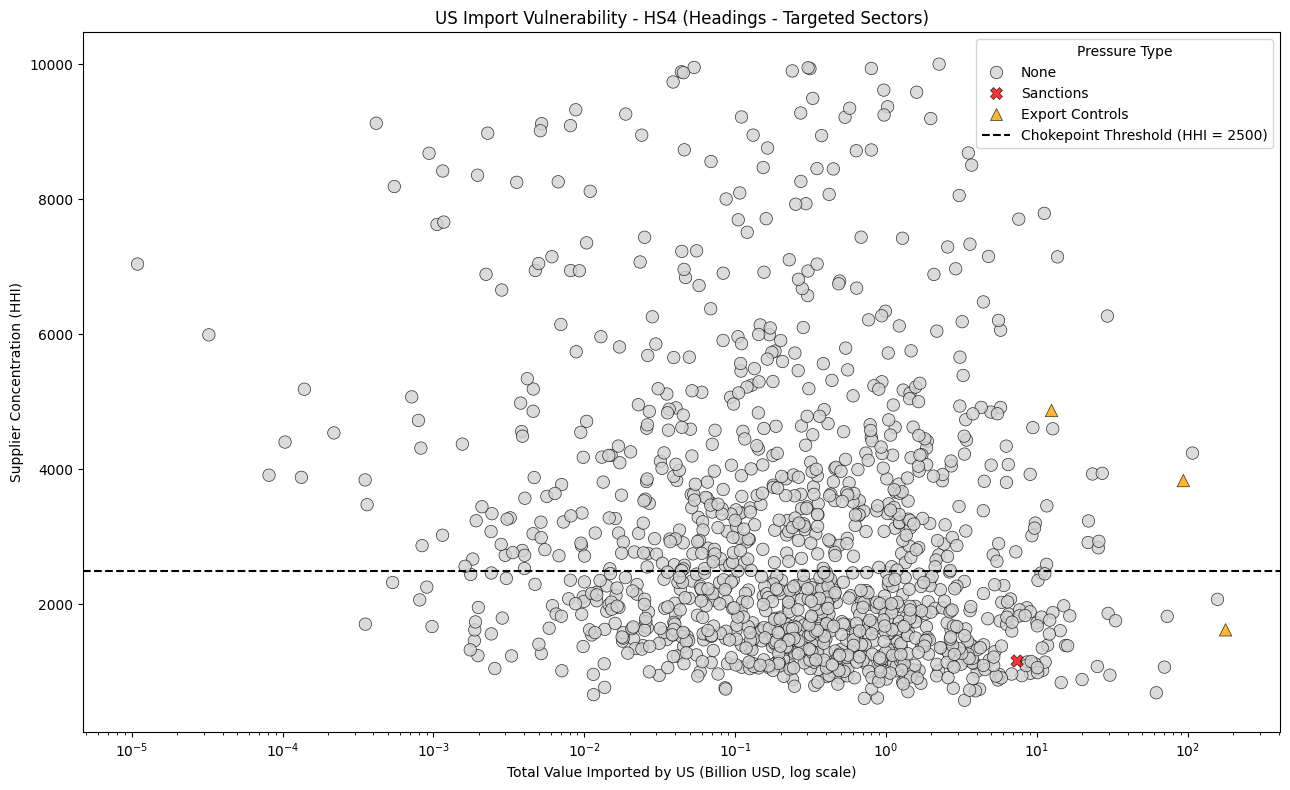

Affichage du graphique US Export Leverage (HS4_agg)


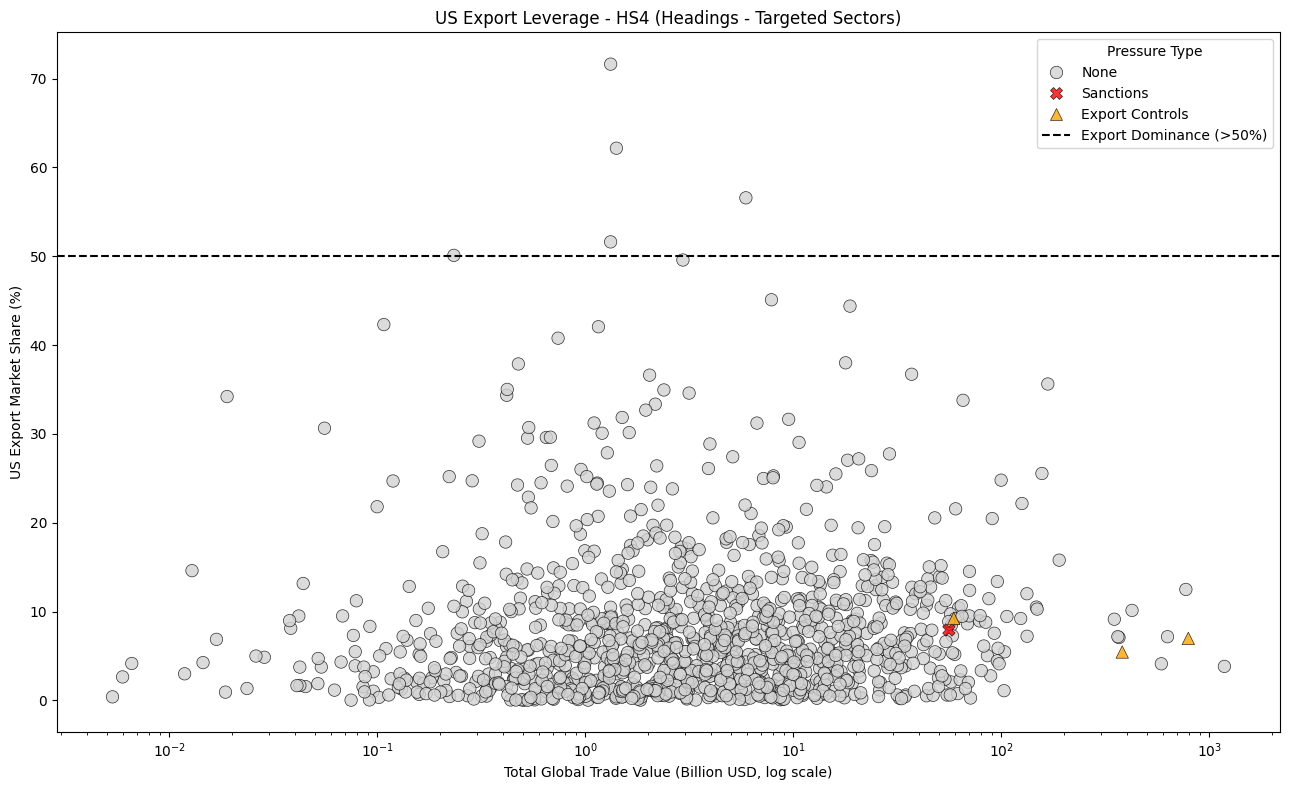


--- Agregation et calcul HHI pour : HS6 (Subheadings - Precise Chokepoints) ---
Affichage du graphique US Import Vulnerability (HS6_agg)


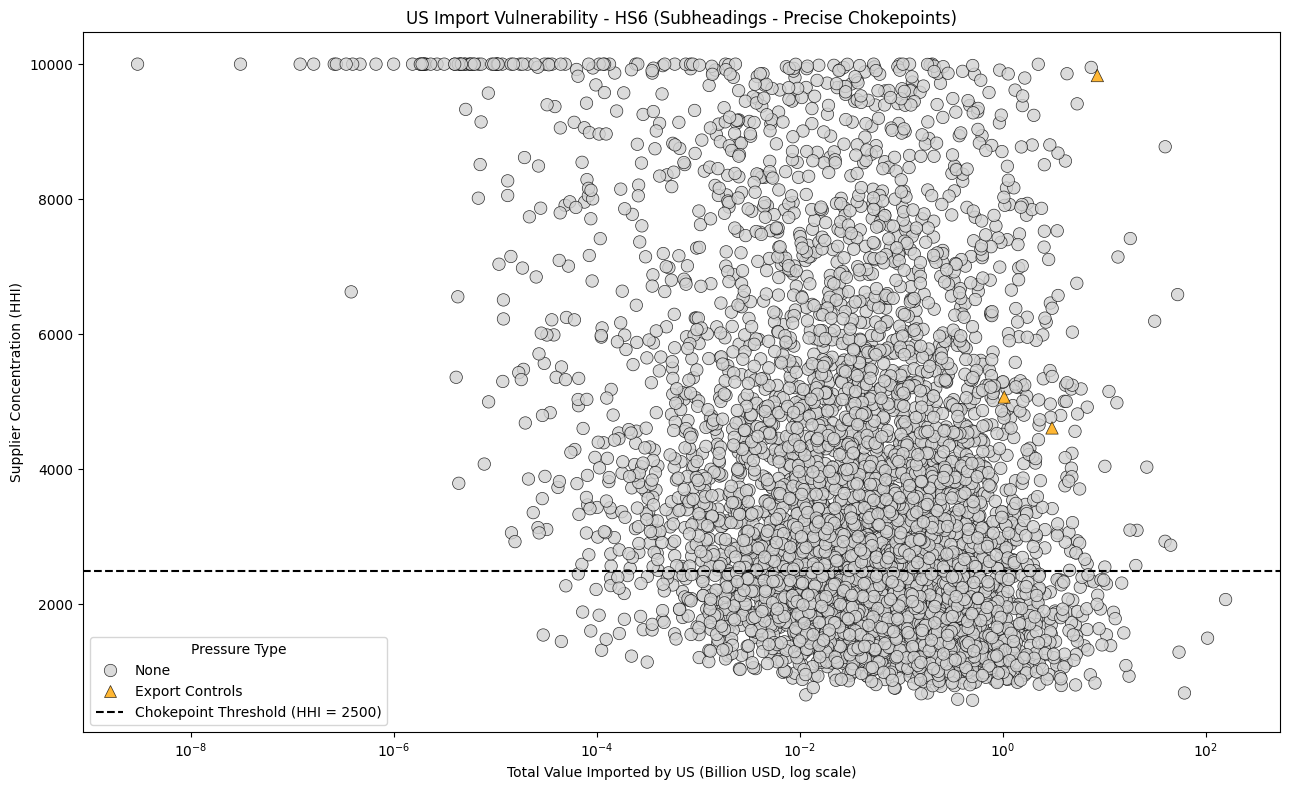

Affichage du graphique US Export Leverage (HS6_agg)


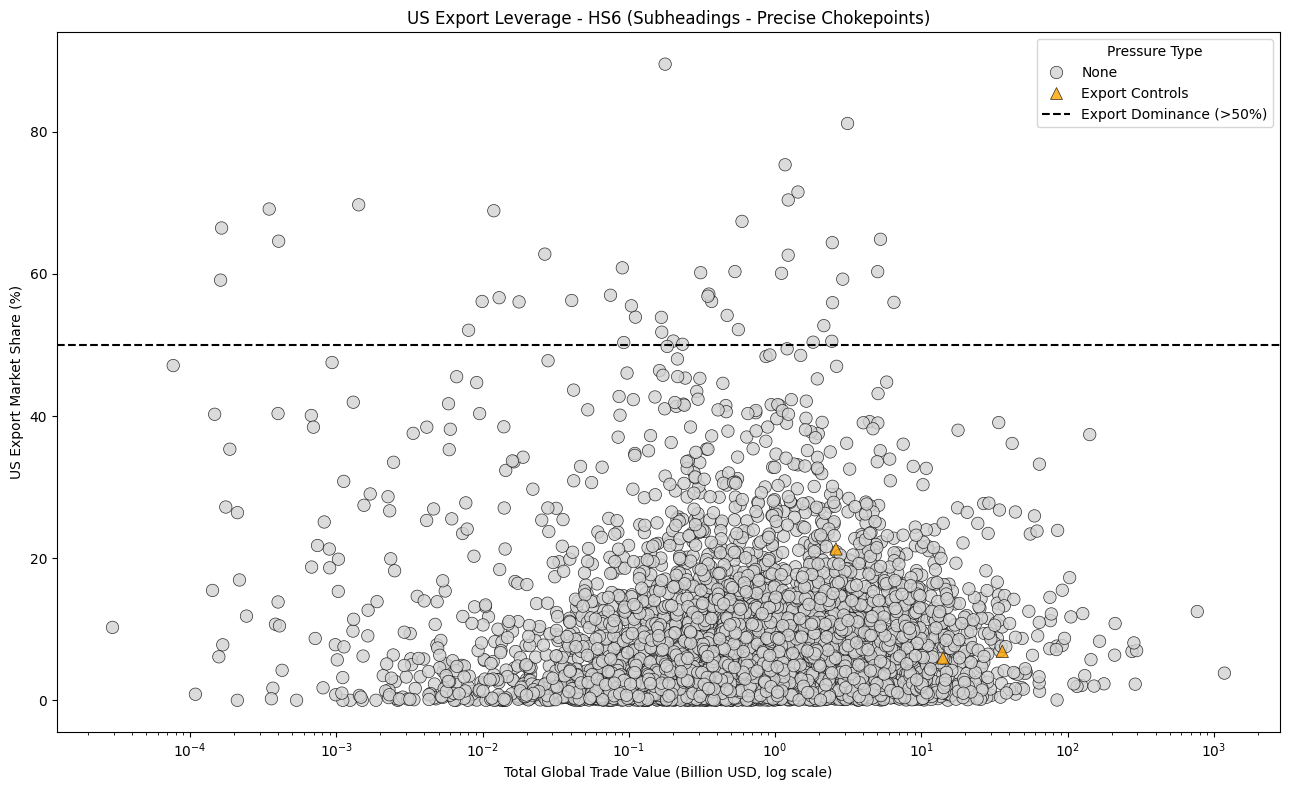

Execution terminee.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("Chargement des fichiers CSV en cours...")
baci_df = pd.read_csv('BACI_HS17_Y2018_V202601.csv', encoding='latin-1')
countries_df = pd.read_csv('country_codes_V202601.csv', encoding='latin-1')
pressure_df = pd.read_csv('results_final_flattened_0.csv', encoding='utf-8')
print("Chargement termine.")

pressure_df = pressure_df[pressure_df['mistral_audit_response'].notna()]
pressure_df = pressure_df[~pressure_df['mistral_audit_response'].astype(str).str.startswith('ERREUR')]

baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)

us_code_row = countries_df[countries_df['country_iso3'] == 'USA']
us_code = us_code_row['country_code'].iloc[0] if not us_code_row.empty else 840

def extract_codes_by_type(prefix):
    codes_2, codes_4, codes_6 = set(), set(), set()
    effect_col = f"{prefix}_effect_any"
    if effect_col in pressure_df.columns:
        filtered_df = pressure_df[pressure_df[effect_col] == 1]
    elif 'global_effect_any' in pressure_df.columns:
        filtered_df = pressure_df[pressure_df['global_effect_any'] == 1]
    else:
        filtered_df = pressure_df
        
    cols = [c for c in filtered_df.columns if c.startswith(prefix) and 'hs_' in c and 'explanation' not in c]
    for col in cols:
        vals = filtered_df[col].dropna().astype(str).str.strip()
        for v_item in vals:
            if v_item.lower() not in ['nan', 'none', 'null', '']:
                for code_part in v_item.split(','):
                    match = re.search(r'(\d+[\.\d]*)', code_part)
                    if match:
                        raw_code = match.group(1).replace('.', '')
                        if len(raw_code) == 1:
                            raw_code = '0' + raw_code
                        if len(raw_code) == 2:
                            codes_2.add(raw_code)
                        elif 3 <= len(raw_code) <= 4:
                            codes_4.add(raw_code.zfill(4))
                        elif len(raw_code) >= 5:
                            codes_6.add(raw_code[:6].zfill(6))
    return codes_2, codes_4, codes_6

print("Extraction des codes douaniers depuis les transcripts...")
t_2, t_4, t_6 = extract_codes_by_type('tariffs')
s_2, s_4, s_6 = extract_codes_by_type('sanctions')
e_2, e_4, e_6 = extract_codes_by_type('exports')

print(f"Codes trouves - Tariffs : HS2({len(t_2)}), HS4({len(t_4)}), HS6({len(t_6)})")
print(f"Codes trouves - Sanctions : HS2({len(s_2)}), HS4({len(s_4)}), HS6({len(s_6)})")
print(f"Codes trouves - Exports : HS2({len(e_2)}), HS4({len(e_4)}), HS6({len(e_6)})")

echelles = [
    ('HS2 (Chapters - Entire Industries)', 2, t_2, s_2, e_2, 'HS2_agg'),
    ('HS4 (Headings - Targeted Sectors)', 4, t_4, s_4, e_4, 'HS4_agg'),
    ('HS6 (Subheadings - Precise Chokepoints)', 6, t_6, s_6, e_6, 'HS6_agg')
]

palette_mesures = {'None': 'lightgrey', 'Tariffs': 'blue', 'Sanctions': 'red', 'Export Controls': 'orange', 'Multiple': 'purple'}
markers_mesures = {'None': 'o', 'Tariffs': 's', 'Sanctions': 'X', 'Export Controls': '^', 'Multiple': 'D'}
order_map = {'None': 0, 'Tariffs': 1, 'Sanctions': 2, 'Export Controls': 3, 'Multiple': 4}

for titre, level, set_t, set_s, set_e, file_suffix in echelles:
    print(f"\n--- Agregation et calcul HHI pour : {titre} ---")
    baci_df['k_agg'] = baci_df['k_str'].str.slice(0, level)
    
    us_imports = baci_df[baci_df['j'] == us_code].copy()
    us_imports_grouped = us_imports.groupby(['k_agg', 'i'])['v'].sum().reset_index()
    us_import_totals = us_imports_grouped.groupby('k_agg')['v'].sum().reset_index(name='us_total_import')
    
    def calc_hhi(v_series):
        shares = (v_series / v_series.sum()) * 100
        return (shares ** 2).sum()
        
    us_import_hhi_df = us_imports_grouped.groupby('k_agg')['v'].apply(calc_hhi).reset_index(name='us_import_hhi')
    base_us_import = us_import_totals.merge(us_import_hhi_df, on='k_agg')
    base_us_import['v_billion'] = base_us_import['us_total_import'] / 1e6
    
    global_exports = baci_df.groupby('k_agg')['v'].sum().reset_index(name='global_total_export')
    us_exports = baci_df[baci_df['i'] == us_code].groupby('k_agg')['v'].sum().reset_index(name='us_export')
    base_us_export = global_exports.merge(us_exports, on='k_agg', how='left').fillna({'us_export': 0})
    base_us_export['us_export_share_%'] = (base_us_export['us_export'] / base_us_export['global_total_export']) * 100
    base_us_export['global_v_billion'] = base_us_export['global_total_export'] / 1e6

    def determine_statut(code):
        in_t = code in set_t
        in_s = code in set_s
        in_e = code in set_e
        total = in_t + in_s + in_e
        if total > 1: return 'Multiple'
        elif in_t: return 'Tariffs'
        elif in_s: return 'Sanctions'
        elif in_e: return 'Export Controls'
        return 'None'

    base_us_import['Statut'] = base_us_import['k_agg'].apply(determine_statut)
    base_us_import['sort_key'] = base_us_import['Statut'].map(order_map)
    base_us_import = base_us_import.sort_values(by='sort_key')
    
    print(f"Affichage du graphique US Import Vulnerability ({file_suffix})")
    plt.figure(figsize=(13, 8))
    sns.scatterplot(
        data=base_us_import, x='v_billion', y='us_import_hhi', 
        hue='Statut', style='Statut', palette=palette_mesures, markers=markers_mesures,
        alpha=0.8, s=80, edgecolor='black', linewidth=0.5
    )
    plt.axhline(2500, color='black', linestyle='--', label='Chokepoint Threshold (HHI = 2500)')
    plt.xscale('log')
    plt.title(f'US Import Vulnerability - {titre}')
    plt.xlabel('Total Value Imported by US (Billion USD, log scale)')
    plt.ylabel('Supplier Concentration (HHI)')
    plt.legend(title='Pressure Type')
    plt.tight_layout()
    plt.savefig(f'us_import_vuln_{file_suffix}.png')
    plt.show()
    plt.close()

    base_us_export['Statut'] = base_us_export['k_agg'].apply(determine_statut)
    base_us_export['sort_key'] = base_us_export['Statut'].map(order_map)
    base_us_export = base_us_export.sort_values(by='sort_key')
    
    print(f"Affichage du graphique US Export Leverage ({file_suffix})")
    plt.figure(figsize=(13, 8))
    sns.scatterplot(
        data=base_us_export, x='global_v_billion', y='us_export_share_%', 
        hue='Statut', style='Statut', palette=palette_mesures, markers=markers_mesures,
        alpha=0.8, s=80, edgecolor='black', linewidth=0.5
    )
    plt.axhline(50, color='black', linestyle='--', label='Export Dominance (>50%)')
    plt.xscale('log')
    plt.title(f'US Export Leverage - {titre}')
    plt.xlabel('Total Global Trade Value (Billion USD, log scale)')
    plt.ylabel('US Export Market Share (%)')
    plt.legend(title='Pressure Type')
    plt.tight_layout()
    plt.savefig(f'us_export_leverage_{file_suffix}.png')
    plt.show()
    plt.close()

print("Execution terminee.")

In [ ]:
import pandas as pd
import re

df = pd.read_csv('results_final_flattened_0.csv', encoding='latin-1')
df = df[df['mistral_audit_response'].notna()]
df = df[~df['mistral_audit_response'].astype(str).str.startswith('ERREUR')]

hs_cols = [c for c in df.columns if 'hs_' in c and 'explanation' not in c]

transcripts_hs2_effect = 0
transcripts_hs2_no_effect = 0
transcripts_hs4_effect = 0
transcripts_hs4_no_effect = 0
transcripts_hs6_effect = 0
transcripts_hs6_no_effect = 0

for index, row in df.iterrows():
    effect = row.get('global_effect_any', 0)
    
    has_hs2 = False
    has_hs4 = False
    has_hs6 = False
    
    for col in hs_cols:
        val = str(row.get(col, '')).strip()
        if val.lower() not in ['nan', 'none', 'null', '']:
            for code_part in val.split(','):
                match = re.search(r'(\d+[\.\d]*)', code_part)
                if match:
                    raw_code = match.group(1).replace('.', '')
                    if len(raw_code) == 1:
                        raw_code = '0' + raw_code
                    if len(raw_code) == 2:
                        has_hs2 = True
                    elif 3 <= len(raw_code) <= 4:
                        has_hs4 = True
                    elif len(raw_code) >= 5:
                        has_hs6 = True
                        
    if has_hs2:
        if effect == 1:
            transcripts_hs2_effect += 1
        else:
            transcripts_hs2_no_effect += 1
            
    if has_hs4:
        if effect == 1:
            transcripts_hs4_effect += 1
        else:
            transcripts_hs4_no_effect += 1
            
    if has_hs6:
        if effect == 1:
            transcripts_hs6_effect += 1
        else:
            transcripts_hs6_no_effect += 1

print("=== TRANSCRIPTS SIGNALANT UN CODE HS2 (Chapitres) ===")
print(f"Avec global_effect_any == 1 : {transcripts_hs2_effect}")
print(f"Sans impact avéré (0 ou NaN) : {transcripts_hs2_no_effect}")

print("\n=== TRANSCRIPTS SIGNALANT UN CODE HS4 (Positions) ===")
print(f"Avec global_effect_any == 1 : {transcripts_hs4_effect}")
print(f"Sans impact avéré (0 ou NaN) : {transcripts_hs4_no_effect}")

print("\n=== TRANSCRIPTS SIGNALANT UN CODE HS6 (Sous-positions) ===")
print(f"Avec global_effect_any == 1 : {transcripts_hs6_effect}")
print(f"Sans impact avéré (0 ou NaN) : {transcripts_hs6_no_effect}")

=== TRANSCRIPTS SIGNALANT UN CODE HS2 (Chapitres) ===
Avec global_effect_any == 1 : 10
Sans impact avéré (0 ou NaN) : 2

=== TRANSCRIPTS SIGNALANT UN CODE HS4 (Positions) ===
Avec global_effect_any == 1 : 7
Sans impact avéré (0 ou NaN) : 3

=== TRANSCRIPTS SIGNALANT UN CODE HS6 (Sous-positions) ===
Avec global_effect_any == 1 : 7
Sans impact avéré (0 ou NaN) : 2


In [10]:
import pandas as pd

df = pd.read_csv('results_final_flattened_0.csv', encoding='utf-8')

correction_cols = ['tariffs_correction_made', 'sanctions_correction_made', 'exports_correction_made']

for col in correction_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_modified = df[
    (df.get('tariffs_correction_made', 0) == 1) | 
    (df.get('sanctions_correction_made', 0) == 1) | 
    (df.get('exports_correction_made', 0) == 1)
]

nb_entreprises = df_modified['company'].nunique()
nb_transcripts = len(df_modified)

print(f"Nombre d'entreprises uniques avec au moins une correction : {nb_entreprises}")
print(f"Nombre total de transcripts corrigés : {nb_transcripts}")

Nombre d'entreprises uniques avec au moins une correction : 48
Nombre total de transcripts corrigés : 69
